# Setup

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [112]:
# Load feature csv
init_df = pd.read_csv("features/features_timeout_15s.csv")
print(len(init_df))

30160


In [115]:
label_of_interest = 17

num_unique_flows = init_df[init_df['Label'] == label_of_interest]['flow_id'].nunique()

print(f"Label {label_of_interest} has {num_unique_flows} unique flow_ids")

Label 17 has 1752 unique flow_ids


In [110]:
# Count rows per flow_id, descending
flow_counts = init_df['flow_id'].value_counts().sort_values(ascending=False)

print("\n=== Top flow_ids by number of rows ===")
top_n = 100
top_flows = flow_counts.head(top_n)

# Merge with Label to show class for each flow_id
# Drop duplicates to get one Label per flow_id
top_flows_classes = (
    init_df[init_df['flow_id'].isin(top_flows.index)]
    [['flow_id', 'Label']]
    .drop_duplicates(subset=['flow_id'])
    .set_index('flow_id')
    .loc[top_flows.index]  # preserve top_n order
)
top_flows_classes['num_rows'] = top_flows
print("\nTop flow_ids with their class and number of rows:")
print(top_flows_classes)


=== Top flow_ids by number of rows ===

Top flow_ids with their class and number of rows:
                  Label  num_rows
flow_id                          
9060008967091294     17       486
8779866313624574      9       219
272794371475837       4       209
7487422694935564     11       204
4391339101682767     15       122
...                 ...       ...
1349718125250387      4        14
4325900198378176      6        14
473035335588458       1        14
2644794800747995      5        14
1832965728221822     12        14

[100 rows x 2 columns]


In [111]:
MAX_FLOWS_PER_ID = 3
filtered_df = (
    init_df
    .groupby('flow_id', group_keys=False)
    .apply(lambda x: x.sample(n=min(len(x), MAX_FLOWS_PER_ID), random_state=42))
    .reset_index(drop=True)
)
print(f"Total rows after filtering: {len(filtered_df)}")

Total rows after filtering: 9999


C:\Users\train\AppData\Local\Temp\ipykernel_14788\1173460057.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), MAX_FLOWS_PER_ID), random_state=42))


In [83]:
flow_counts = filtered_df['flow_id'].value_counts().sort_index()
print("\n=== Number of rows per flow_id after filtering ===")
print(flow_counts)
print("\n=== Flow statistics after filtering ===")
print(f"Number of unique flow_ids: {filtered_df['flow_id'].nunique()}")
print(f"Min flows per id: {flow_counts.min()}")
print(f"Max flows per id: {flow_counts.max()}")
print(f"Mean flows per id: {flow_counts.mean():.2f}")
print(f"Median flows per id: {flow_counts.median()}")


=== Number of rows per flow_id after filtering ===
flow_id
208245151268        1
2249841235455       3
3990137951595       2
5064949320163       3
5872391925013       2
                   ..
9998054739799069    2
9998115155601681    1
9998511112479929    1
9999429499600996    1
9999883343095006    2
Name: count, Length: 13621, dtype: int64

=== Flow statistics after filtering ===
Number of unique flow_ids: 13621
Min flows per id: 1
Max flows per id: 3
Mean flows per id: 1.44
Median flows per id: 1.0


In [84]:
init_df = filtered_df.copy()

In [76]:
exclude_cols = ['flow_id', 'protocol', 'Label']
cols_to_aggregate = [c for c in init_df .columns if c not in exclude_cols and pd.api.types.is_numeric_dtype(init_df [c])]
agg_df = init_df.groupby('Label')[cols_to_aggregate].agg(['min', 'max', 'mean'])
agg_df.columns = ['_'.join(col).strip() for col in agg_df.columns.values]

print(agg_df)

       duration_min  duration_max  duration_mean  pkts_fwd_min  pkts_fwd_max  \
Label                                                                          
0          0.000250     14.967597       0.520142             1           126   
1          0.000386     14.989586       0.712881             1           118   
2          0.000211     14.998892       0.848845             1           311   
3          0.000175     14.999644       0.865602             1           177   
4          0.000284      6.318761       0.416143             1            17   
5          0.000037     14.999668       0.847629             1            71   
6          0.000055     14.999264       1.592346             1         64041   
7          0.000216     13.013191       0.591724             1         42724   
8          0.000043     14.994048       1.119600             1         18636   
9          0.000376     14.991914       1.854023             1           713   
10         0.000302     14.998182       

In [27]:
# Text to Index and Index to Text mappings
T2I = {
    # CHAT
    "aim": 0,
    "facebook_chat": 1,
    "gmail": 21,
    "hangouts_chat": 2,
    "skype_chat": 3,
    "icq": 4,

    # EMAIL
    "email": 5,

    # FILE TRANSFER
    "ftps": 6,
    "scp": 7,
    "sftp": 8,
    "skype_file": 9,

    # STREAMING
    "netflix": 10,
    "spotify": 11, 
    "vimeo" : 12,
    "youtube": 13,

    # VOIP
    "facebook_audio": 14,
    "hangouts_audio": 15,
    "skype_audio": 16,
    "voipbuster": 17,

    # VIDEO CALL
    "facebook_video": 18,
    "skype_video": 19,
    "hangouts_video": 20
}
I2T = {v: k for k, v in T2I.items()}

# Utils

In [28]:
def plot_class_distribution(df):
    class_counts = df["Label"].value_counts().sort_index()
    print(class_counts)
    class_percent = class_counts / class_counts.sum() * 100
    print(class_percent)
    print(f"Mean flow ")

    # mapare index -> text
    labels_text = [I2T.get(i, f"unk_{i}") for i in class_counts.index]

    plt.figure(figsize=(10, 4))
    plt.bar(labels_text, class_percent.values)
    plt.xticks(rotation=45, ha="right")

    plt.xlabel("Class")
    plt.ylabel("Percentage of flows")
    plt.title("Class distribution")

    plt.tight_layout()
    plt.show()

def plot_mean_packet_count(df):
    df["total_pkts"] = df["pkts_fwd"] + df["pkts_bwd"]
    mean_pkts_per_class = df.groupby("Label")["total_pkts"].mean()
    print(mean_pkts_per_class)

    # mapare index -> text
    labels_text = [I2T.get(i, f"unk_{i}") for i in mean_pkts_per_class.index]

    plt.figure(figsize=(10, 4))
    plt.bar(labels_text, mean_pkts_per_class.values)
    plt.xticks(rotation=45, ha="right")

    plt.xlabel("Class")
    plt.ylabel("Mean packet count")
    plt.title("Mean packets count per class")

    plt.tight_layout()
    plt.show()

def plot_mean_packet_len(df):
    df["mean_pkt_len_total"] = (
        df["pkts_fwd"] * df["mean_pkt_len_fwd"] +
        df["pkts_bwd"] * df["mean_pkt_len_bwd"]
    ) / (df["pkts_fwd"] + df["pkts_bwd"])
    mean_pkt_len_per_class = df.groupby("Label")["mean_pkt_len_total"].mean()
    print(mean_pkt_len_per_class)

    # mapare index -> text
    labels_text = [I2T.get(i, f"unk_{i}") for i in mean_pkt_len_per_class.index]

    plt.figure(figsize=(10, 4))
    plt.bar(labels_text, mean_pkt_len_per_class.values)
    plt.xticks(rotation=45, ha="right")

    plt.xlabel("Class")
    plt.ylabel("Mean packet length")
    plt.title("Mean packet length per flow")

    plt.tight_layout()
    plt.show()

# Initial Data Distribution

## Class distribution

Label
0      363
1      391
2      459
3     3609
4      361
5     3986
6      883
7      170
8      185
9      160
10     586
11     344
12     597
13    1244
14     447
15    1817
16     190
17    1843
18     454
19      61
20    1414
Name: count, dtype: int64
Label
0      1.855449
1      1.998569
2      2.346146
3     18.447148
4      1.845226
5     20.374157
6      4.513392
7      0.868943
8      0.945614
9      0.817829
10     2.995297
11     1.758332
12     3.051523
13     6.358618
14     2.284809
15     9.287467
16     0.971172
17     9.420364
18     2.320589
19     0.311797
20     7.227561
Name: count, dtype: float64
Mean flow 


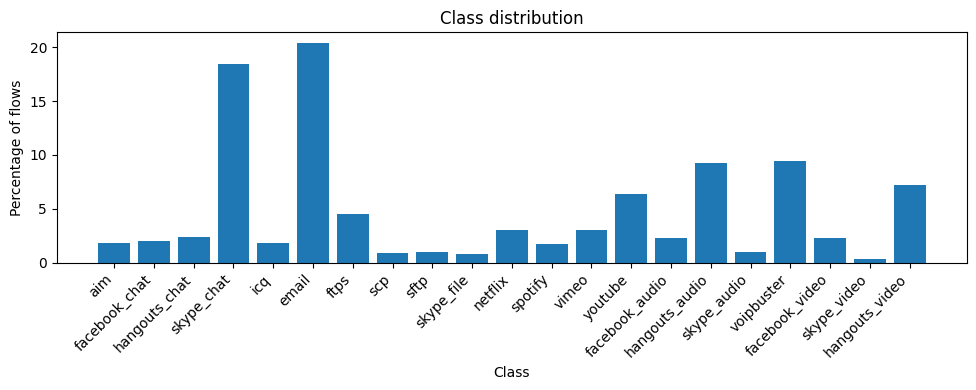

In [87]:
plot_class_distribution(init_df)

## Mean packet count per class

Label
0        4.636364
1        5.107417
2        8.422658
3        3.294819
4        2.481994
5        4.629453
6     2144.651189
7     2635.852941
8      467.189189
9       15.193750
10      79.363481
11      51.133721
12     111.649916
13     141.852090
14      33.163311
15       9.152999
16       3.573684
17       5.530114
18     109.167401
19     140.245902
20      22.794201
Name: total_pkts, dtype: float64


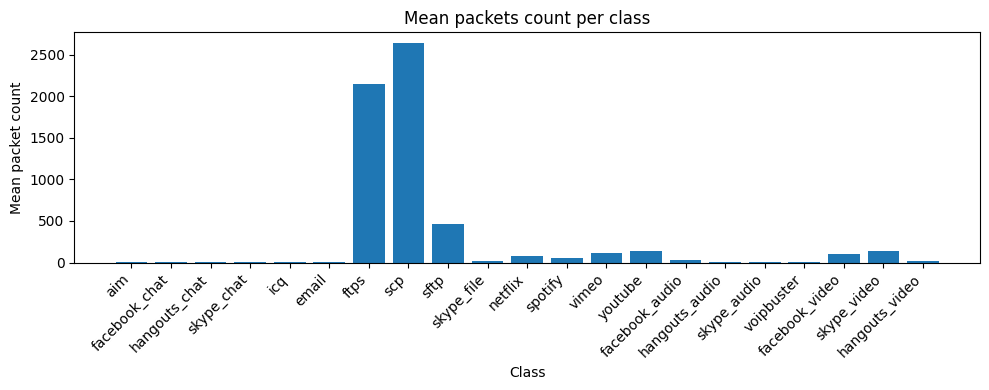

In [88]:
plot_mean_packet_count(init_df)

## Mean packet length per class

Label
0      87.610426
1     113.818383
2     140.218894
3      83.733869
4      77.280909
5      81.372189
6     340.375802
7     381.715947
8     249.227089
9     198.798499
10    231.078584
11    214.896382
12    263.177589
13    168.682421
14    131.426085
15    175.876093
16    114.930059
17     78.466397
18    139.018285
19    203.373278
20    177.368622
Name: mean_pkt_len_total, dtype: float64


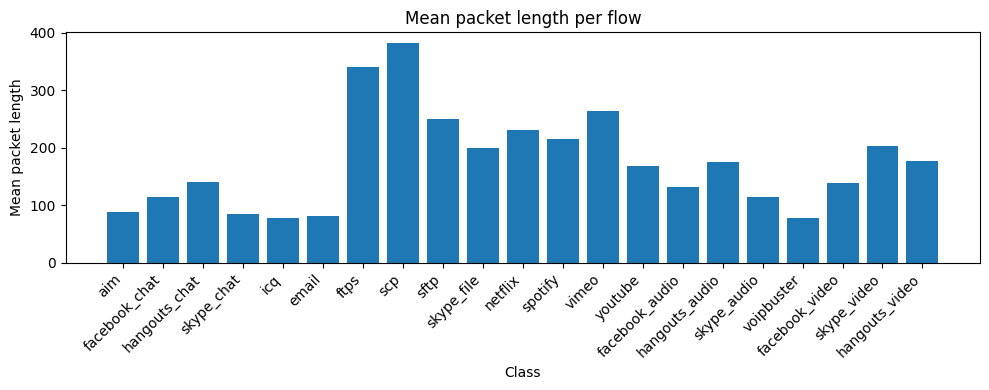

In [89]:
plot_mean_packet_len(init_df)

# Filter out flows

In [57]:
# Filter out short flows (at least 2 packets either side)
# valid_mask = (init_df["pkts_fwd"] >= 2) & (init_df["pkts_bwd"] >= 2)
valid_mask = (init_df["pkts_fwd"] >= 1) & (init_df["pkts_bwd"] >= 1)

# Eliminate flows
eliminated_df = init_df[~valid_mask]

# Keep others
filtered_df = init_df[valid_mask]

print(f"Initial flows: {len(init_df)}")
print(f"Eliminated flows: {len(eliminated_df)}")
print(f"Remaining flows: {len(filtered_df)}")

Initial flows: 30160
Eliminated flows: 13546
Remaining flows: 16614


In [59]:
eliminated_df['total_pkts'] = eliminated_df["pkts_fwd"] + eliminated_df['pkts_bwd']
mean_pkts_per_flow = eliminated_df['total_pkts'].mean()
print(mean_pkts_per_flow)

3.521703824007087


C:\Users\train\AppData\Local\Temp\ipykernel_14788\1908456950.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  eliminated_df['total_pkts'] = eliminated_df["pkts_fwd"] + eliminated_df['pkts_bwd']


Class distribution of ELIMINATED flows:
Label
0      349
1      335
2      366
3     5335
4      364
5     4641
6       98
8       45
9        1
10       6
11      19
12       6
13      22
14      12
15      24
16       5
17    1877
18      18
19       6
20      17
Name: count, dtype: int64
Label
0      2.576406
1      2.473055
2      2.701905
3     39.384320
4      2.687140
5     34.261036
6      0.723461
8      0.332201
9      0.007382
10     0.044294
11     0.140263
12     0.044294
13     0.162410
14     0.088587
15     0.177174
16     0.036911
17    13.856489
18     0.132881
19     0.044294
20     0.125498
Name: count, dtype: float64
Mean flow 


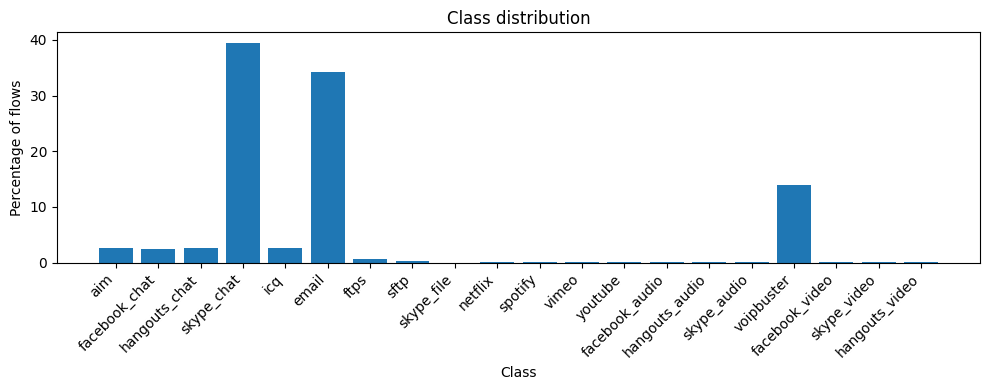

In [58]:
print("Class distribution of ELIMINATED flows:")
plot_class_distribution(eliminated_df)

Class distribution AFTER filtering:
Label
0      212
1      204
2      349
3      643
4      232
5     1190
6     1360
7      171
8      199
9      263
10    1197
11     690
12     913
13    1762
14     636
15    2500
16     414
17     873
18     599
19     278
20    1929
Name: count, dtype: int64
Label
0      1.276032
1      1.227880
2      2.100638
3      3.870230
4      1.396413
5      7.162634
6      8.185867
7      1.029252
8      1.197785
9      1.583002
10     7.204767
11     4.153124
12     5.495365
13    10.605513
14     3.828097
15    15.047550
16     2.491874
17     5.254605
18     3.605393
19     1.673288
20    11.610690
Name: count, dtype: float64
Mean flow 


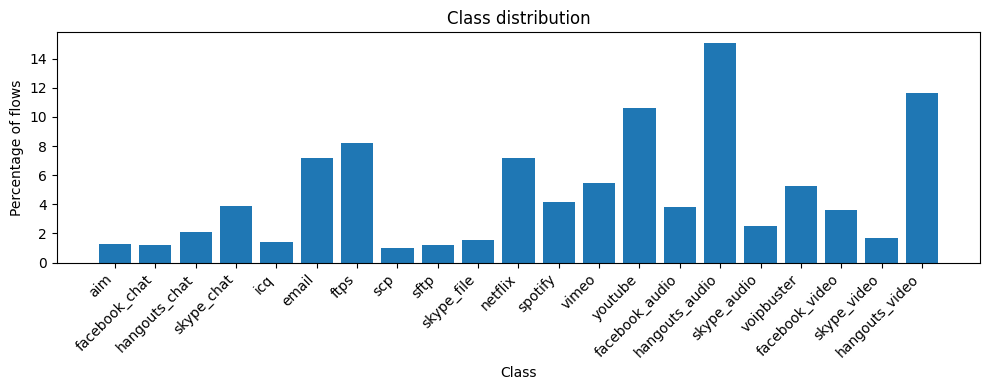

In [43]:
print("Class distribution AFTER filtering:")
plot_class_distribution(filtered_df)

In [90]:
# Drop useless columns
cols = []
columns_to_drop = ['total_pkts', 'mean_pkt_len_total']
for col in columns_to_drop:
    if col in filtered_df.columns:
        cols.append(col)
filtered_df = filtered_df.drop(columns=cols)

# Data Imputation

In [91]:
for col in filtered_df.columns:
    n_nan = filtered_df[col].isna().sum()
    if n_nan == 0:
        continue

    col_lower = col.lower()

    if any(k in col_lower for k in ["mean", "median", "std", 'total', 'persecond', "skew", "kurtosis"]):
        filtered_df[col] = filtered_df[col].fillna(0)
        print(f"{col}: filled {n_nan} NaNs with 0")

    elif any(k in col_lower for k in ["min", "max"]):
        filtered_df[col] = filtered_df[col].fillna(-1)
        print(f"{col}: filled {n_nan} NaNs with -1")

    else:
        print(f"{col}: {n_nan} NaNs → NO RULE")

total_fiat: filled 6551 NaNs with 0
mean_fiat: filled 6551 NaNs with 0
median_fiat: filled 6551 NaNs with 0
min_fiat: filled 6551 NaNs with -1
max_fiat: filled 6551 NaNs with -1
std_fiat: filled 6551 NaNs with 0
total_biat: filled 16565 NaNs with 0
mean_biat: filled 16565 NaNs with 0
median_biat: filled 16565 NaNs with 0
min_biat: filled 16565 NaNs with -1
max_biat: filled 16565 NaNs with -1
std_biat: filled 16565 NaNs with 0
flowiat_skew: filled 16339 NaNs with 0
flowiat_kurtosis: filled 17009 NaNs with 0
size_skewness: filled 16750 NaNs with 0
size_kurtosis: filled 16907 NaNs with 0


In [92]:
# Save new csv
csv_path = "features/features_timeout_15s_id_filtered.csv"
filtered_df.to_csv(csv_path, index=False)
print(f"Saved cleaned dataset to: {csv_path}")

Saved cleaned dataset to: features/features_timeout_15s_id_filtered.csv


Class distribution imputed:
Label
0      445
1      486
2      651
3     5867
4      466
5     5292
6      598
7       15
8      156
9      156
10     351
11     250
12     487
13    1065
14     360
15     768
16     200
17    2644
18     389
19     196
20     570
Name: count, dtype: int64
Label
0      2.078274
1      2.269755
2      3.040351
3     27.400523
4      2.176350
5     24.715113
6      2.792826
7      0.070054
8      0.728563
9      0.728563
10     1.639268
11     1.167570
12     2.274426
13     4.973846
14     1.681300
15     3.586774
16     0.934056
17    12.348216
18     1.816738
19     0.915375
20     2.662059
Name: count, dtype: float64


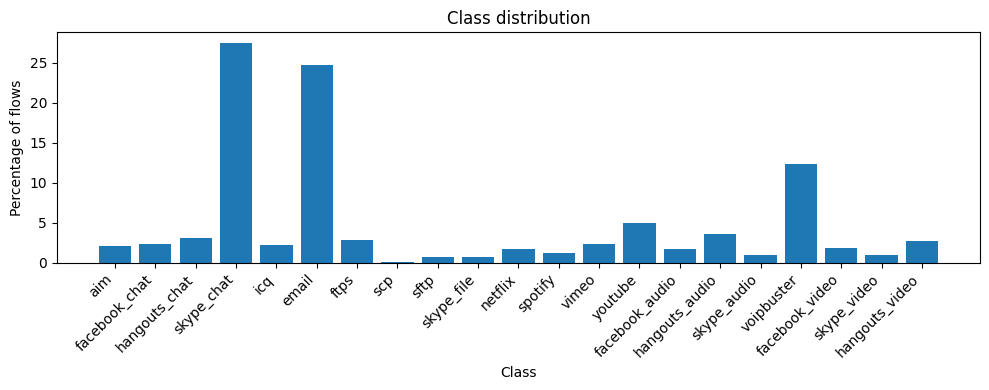

In [57]:
print("Class distribution imputed:")
plot_class_distribution(filtered_df)

# Drop NaNs

Total flows: 21412
Eliminated (with NaN): 16042
Remaining (no NaN): 5370
Class distribution of eliminated flows:


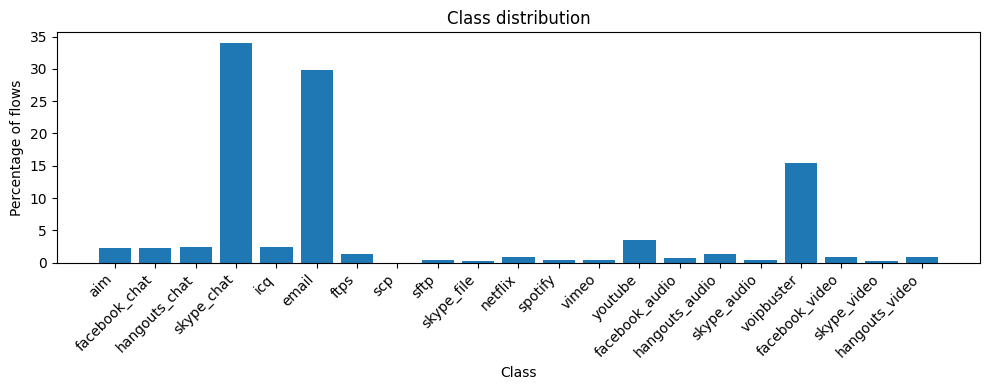

Class distribution before NaN removal:


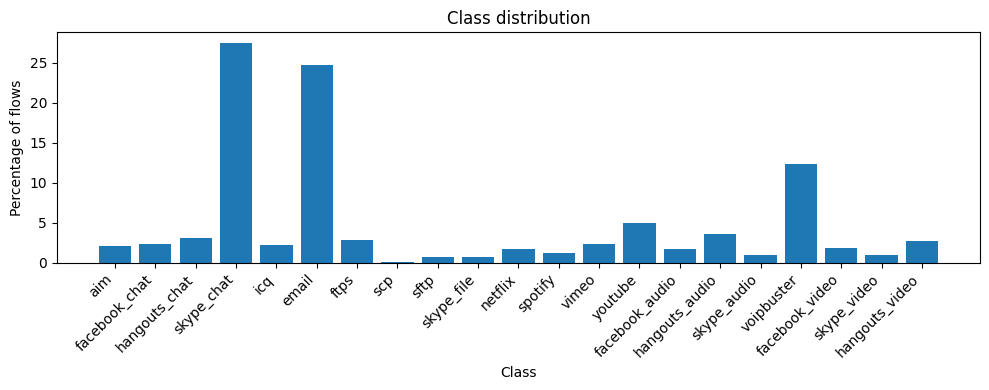

Class distribution after NaN removal:


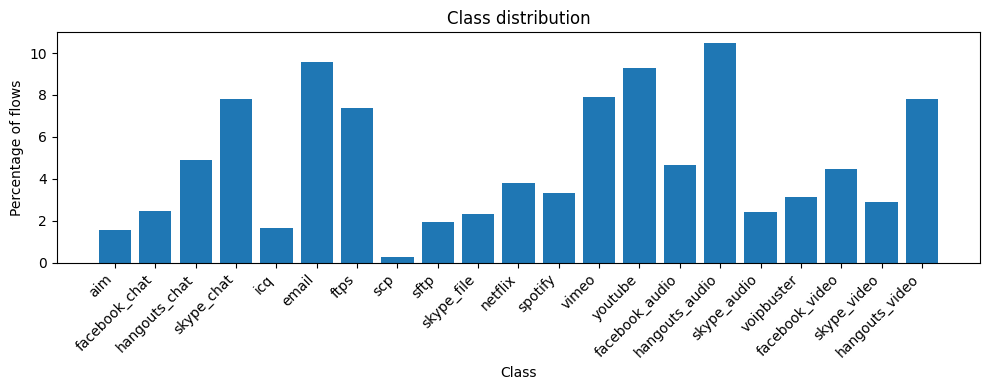

Sanity check: True


In [45]:
filtered_df_2 = filtered_df.copy(deep=True)
rows_with_nan = filtered_df_2[filtered_df_2.isna().any(axis=1)]
df_no_nan = filtered_df_2.dropna()

print(f"Total flows: {len(filtered_df_2)}")
print(f"Eliminated (with NaN): {len(rows_with_nan)}")
print(f"Remaining (no NaN): {len(df_no_nan)}")

print("Class distribution of eliminated flows:")
plot_class_distribution(rows_with_nan)

print("Class distribution before NaN removal:")
plot_class_distribution(filtered_df_2)

print("Class distribution after NaN removal:")
plot_class_distribution(df_no_nan)

print(f"Sanity check: {df_no_nan.isna().sum().sum() == 0}")

In [ ]:
# Save new csv
csv_path = "features/features_timeout_15s_filtered.csv"
df_no_nan.to_csv(csv_path, index=False)
print(f"Saved cleaned dataset to: {csv_path}")

Saved cleaned dataet to: features/features_timeout_15s_filtered.csv


Total flows remaining: 5370
Label
0      84
1     132
2     264
3     420
4      88
5     515
6     397
7      14
8     103
9     124
10    203
11    178
12    425
13    498
14    251
15    562
16    130
17    169
18    239
19    155
20    419
Name: count, dtype: int64
Label
0      1.564246
1      2.458101
2      4.916201
3      7.821229
4      1.638734
5      9.590317
6      7.392924
7      0.260708
8      1.918063
9      2.309125
10     3.780261
11     3.314711
12     7.914339
13     9.273743
14     4.674115
15    10.465549
16     2.420857
17     3.147114
18     4.450652
19     2.886406
20     7.802607
Name: count, dtype: float64


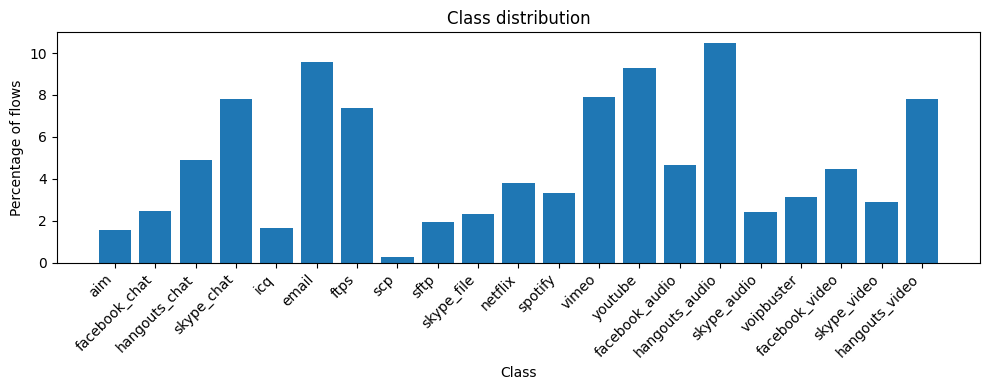

In [58]:
print(f"Total flows remaining: {len(df_no_nan)}")
plot_class_distribution(df_no_nan)